# Question 1
## Supervised learning in a broad context
### Introduction

According to Hastie et al. (2009), there are three types of statistical learning problems, namely supervised, unsupervised and semi-supervised learning. Supervised learning algorithms aim to predict one or more quantities, referred to as the response value (vector) $\mathbf{Y}\in\mathbb{R}^q$, using variables $\mathbf{X}\in\mathbb{R}^p$, also called features. An example of such a learning problem is predicting the probability of a patient having a heart attack based on features such as their heart rate and blood pressure. In contrast, unsupervised learning algorithms only observe features and aim to learn how data is organised or clustered. Clustering methods can, for example, be applied to clinical data to identify groups of patients with different survival rates. As the name, semi-supervised, suggests, this learning problem combines supervised and unsupervised learning, with features present but only some observations have corresponding responses. Supervised learning will be the focus for the remainder of this chapter. 


### The probabilistic approach to supervised learning
As stated previously, the objective of supervised statistical learning algorithms is to predict some unknown response $\mathbf{Y}$ from the corresponding features $\mathbf{X}$ with some general real-valued function $f:\mathcal{X}\rightarrow \mathbb{R}^p$ referred to as the candidate model. This model is estimated by fitting it to observed data, $D=\{(\mathbf{x}_i,\mathbf{y}_i):i=1,...N\}$ where  N denotes the number of observations, $\mathbf{x}_i\in\mathcal{X}\in\mathbb{R}^p$ and $\mathbf{x}_i\in\mathcal{X}\in\mathbb{R}^p$. Hastie et al. (2009) claims this objective is achieved by assuming that $(\mathbf{X},\mathbf{Y})$ are random vectors with a probability density function $\ddot{\mathbb{P}}_{\mathbf{X,Y}}:\mathcal{X}.\mathcal{Y}\rightarrow[0,\infty)$ such that the observations in D are identically, independently distributed according to $\ddot{\mathbb{P}}$. It follows that supervised learning methods, therefore, try to fit a model, $\hat{f}(\mathbf{x})$, to the observed data, $D$, to predict $\mathbf{Y}$ with  $\hat{f}(\mathbf{X})$.

Depending on the response data type, different supervised learning problems arise. When $\mathbf{Y}$ is numeric, predictions are made with regression and more specifically, if $q>1$, the problem becomes multiple output regression. When $\mathbf{Y}$ is categorical, the aim is to solve a classification problem. As with regression, classification can be branched out further into binary, multi-class and multi-label classification. Binary classification problems predict a binary categorical variable, $Y\in\{0,1\}$. When Y needs to be classified into one of $k>2$ classes, the problem is multi-class classification, but when the response can be classified into more than one class and a vector of categorical variables is therefore predicted, the problem is multi-label classification. Hastie et al. (2009)

To illustrate the difference between these supervised learning problems, consider, for example, the medical domain in which various predictions can be made. If the probability of a single patient getting infected with a disease should be predicted, the predicted value will be a continuous number between zero and one and therefore, this is a regression problem. When one wants to predict whether a patient is infected or not, the predicted outcomes can be encoded as zero if the patient is not infected and one otherwise. This is therefore a binary classification problem. When a patient is suffering from one of ten possible diseases, and the aim is to predict which disease the patient is suffering from, this becomes a multi-class classification problem since the response is categorical with more than two possible outcomes.



### The role of loss functions
Hastie et al. (2009) claims that supervised learning problems can be solved with discriminative or generative modelling. The generative approach aims to estimate the distribution of $\mathbf{Y}|\mathbf{X}$ by first estimating $\ddot{\mathbb{P}}_{\mathbf{X,Y}}$. Finally, the estimated distribution of $\mathbf{Y}|\mathbf{X}$ is then used for prediction. In contrast, discriminative modelling focuses on estimating $\ddot{\mathbb{P}}_{\mathbf{X}}$ nonparametrically in order to extract information from the distribution $\mathbf{Y}|\mathbf{X}$ to ultimately make predictions. The discriminative approach, therefore, estimates the distribution of $\mathbf{Y}|\mathbf{X}$ directly by training a model, $\hat{f}$, using the structure of $\mathbf{X}$. 

There are various models that can be used to predict $\mathbf{Y}$. According to Hastie et al. (2009), discriminative modelling defines the optimal model as $\ddot{f}=argmin_{f}[\ddot{\mathcal{R}}(f)]$. Therefore, the optimal model, also known in this setting as the population minimiser, minimises the population risk, $\ddot{\mathcal{R}}(f)=E_{\mathbf{X, Y}}[\mathcal{L}(\mathbf{Y},f(\mathbf{X}))]$. In this formulation $\mathcal{L}(\mathbf{Y},f(\mathbf{X}))$ is some loss function $\mathcal{L}:\mathcal{Y}\times\mathbb{R}^r\rightarrow[0,\infty)$ that quantifies the loss occured when $f(\mathbf{X})$ is used to predict $\mathbf{Y}$. Equivalently, the model that minimises the loss function will be the best model. 

Just as different models can be found to fit data, different loss functions can be employed to find the best model. Intuitively, different loss functions will yield different optimal models. To show this, consider two well-known loss functions, the squared-error loss, $\mathcal{L}(Y,f(\mathbf{X}))=(Y-f(\mathbf{X}))^2$, and absolute loss, $\mathcal{L}(Y,f(\mathbf{X}))=|Y-f(\mathbf{X})|$. The optimal model for $\mathbf{X}=\mathbf{x}$ using the squared-error loss is derived as Hastie et al. (2009):
$$
\begin{align*}
  \ddot{f}(\mathbf{x})&=argmin_{f}[E((Y-f(\mathbf{X}))^2|\mathbf{X}=\mathbf{x})] \\
  &=argmin_{f}[E{(Y^2|\mathbf{X}=\mathbf{x})-2f(\mathbf{x})E(Y|\mathbf{X}=\mathbf{x})+f(\mathbf{x})^2}] \\
\therefore \text{ The expression }&\text{will be minimized when } f(\mathbf{x})E(Y|\mathbf{X}=\mathbf{x})=f(\mathbf{x})^2 \\
\therefore& \ddot{f}(\mathbf{x})= E(Y|\mathbf{X}=\mathbf{x}) \\
\end{align*}
$$

It follows that a similar procedure can be followed for the absolute loss, and although the calculations are not as simple, it can be derived that the population minimiser at $\mathbf{X=x}$ is equal to the median of $\mathbf{Y}|\mathbf{X=x}$. It is therefore shown that two different loss functions result in different optimal models. The squared error loss is simpler to work with, but it is less robust than the absolute loss. Loss functions should therefore be carefully chosen after considering the nature of the supervised learning problem.

Another common loss function, specifically used in classification, is the 0-1 loss, 
$$
\mathcal{L}_{0-1}(Y,f(\mathbf{X}))=\begin{cases}
                                0 &\text{if } Y=f(\mathbf{X}), \\
                                1 &\text{if } Y\ne f(\mathbf{X}). 
                              \end{cases}
$$

The derivation for finding the corresponding optimal model follows as:
$$
\begin{align*}
  \ddot{f}(\mathbf{x})&=argmin_{f}[E(\mathbb{I}(Y\ne f(\mathbf{x}))|\mathbf{X}=\mathbf{x})] \\
  &= argmin_{f}[p(\mathbf{x})\mathbb{I}(1 \ne f(\mathbf{x}))+(1-p(\mathbf{x}))\mathbb{I}(0 \ne f(\mathbf{x}))] \\
  &= argmin_{f}[p(\mathbf{x})\mathbb{I}(0 = f(\mathbf{x}))+(1-p(\mathbf{x}))(1-\mathbb{I}(0 = f(\mathbf{x})))] \\
  &= argmin_{f}\begin{cases}
                    p(\mathbf{x}) &\text{if } f(\mathbf{x})=0, \\
                    1-p(\mathbf{x}) &\text{if } f(\mathbf{x})=1. \\
               \end{cases}\\
\therefore \ddot{f}(\mathbf{x})&=\begin{cases}
                                0 &\text{if } p(\mathbf{x})<0.5, \\
                                1 &\text{if } p(\mathbf{x})\ge 0.5. 
                              \end{cases}
\end{align*}
$$ 

Since this loss function is used in classification problems, the optimal model is not a spesific quantity as with the squared error loss and absolute error loss, but rather a decision boundary. To show how this would look visualy, this 0-1 loss function was applied to a logistic regression problem which required patients to be classified as heart attack risk patients (Y=1) or not (Y=0) based on their age ($X_1$) and cholestrol levels ($X_2$). The first step in this application is to simulate a sample of size n = 200 from the true data generating mechanism, $Y\sim Ber(p)$ with $p=[1+e^{\mathbf{-X\beta}}]^{-1}$ where $\mathbf{\beta}'=[\beta_0,\beta_1,\beta_2]=[-2,0.02,0.01]$, $\mathbf{X}'=[X_1,X_2]$, $X_1\sim N(50,10)$ and $X_2\sim N(200,30)$.  

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
      
Beta = [-2, 0.02, 0.01]      

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def generate_data(n):
    age= np.random.normal(loc=50, scale=10, size=n)           
    cholesterol = np.random.normal(loc=200, scale=30, size=n)  
    X = np.column_stack((age, cholesterol))
    X_design = np.c_[np.ones(X.shape[0]), X] 
    z = X_design @ Beta
    p = sigmoid(z)
    y = np.random.binomial(1, p)

    return X, y

np.random.seed(123)
X, y = generate_data(1000)

Next a heatmap was contructed to visualise $E(\mathcal{L}_{0-1}(Y,f(\mathbf{X})))$ for varying values of $\beta_1$ and $\beta_2$ while keeping $\beta_0$ fixed.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

b1 = np.linspace(-1, 1, 500)
b2 = np.linspace(-1, 1, 500)
B1, B2 = np.meshgrid(b1, b2)
X_design = np.c_[np.ones(X.shape[0]), X] 

loss = np.zeros_like(B1)
for i in range(B1.shape[0]):
    for j in range(B1.shape[1]):
        beta = np.array([-2, B1[i, j], B2[i, j]])
        p_model = sigmoid(X_design @ beta)
        yhat = (p_model >= 0.5).astype(int)
        loss[i, j] = np.mean(yhat != y)


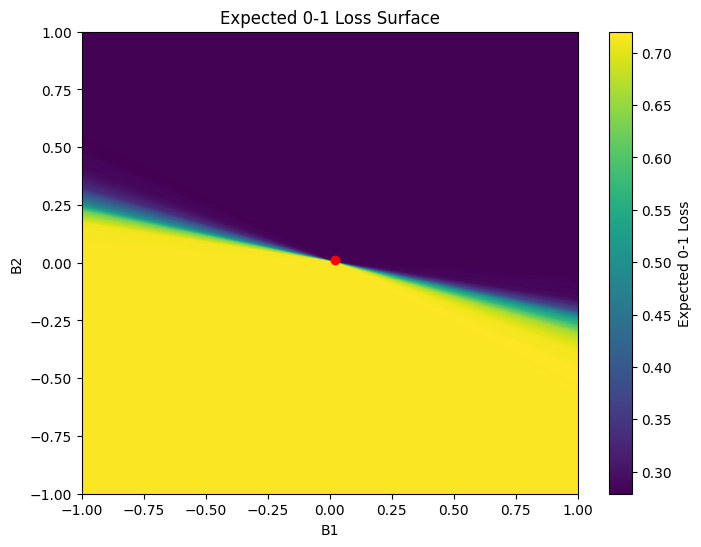

In [4]:

plt.figure(figsize=(8,6))
plt.imshow(loss, origin='lower', extent=[b1.min(), b1.max(), b2.min(), b2.max()], aspect='auto')
plt.plot(0.02,0.01,"ro")
plt.colorbar(label="Expected 0-1 Loss")
plt.xlabel("B1")
plt.ylabel("B2")
plt.title("Expected 0-1 Loss Surface")
plt.show()


As expcted, the heatmap does not show $E(\mathcal{L}_{0-1}(Y,f(\mathbf{X})))$ to have a minimum at a certain point but rather indicates a decision boundary at the true parameter values. This aligns with what was derived analytically.

### Empirical risk and regularisation
In the previous section, it was discussed how to find the optimal model for a supervised learning problem. When we only consider models in the model space $\mathcal{F}$, $\ddot{f}$ can be approximated with $\dot{f}=argmin_{f\in \mathcal{F}}[\ddot{\mathcal{R}}(f)]$. To find a $\dot{f}$, however, the data from the whole population or the true data-generating mechanism is required. Since this is almost never available in practice, the population minimiser can be approximated with an optimal model,$\hat{f}$ that minimises the empirical risk, $\hat{\mathcal{R}}(f,\mathcal{D})=\frac{1}{|D|}\sum_{(\mathbf{(x,y)})\in \mathcal{D}}\mathcal{L}(\mathbf{y},f(\mathbf{x}))$. This is equivalent to the optimasation problem $$\hat{f}(.,\mathcal{D})=argmin_{f\in \mathcal{F}}[\hat{\mathcal{R}}(f,\mathcal{D})] \tag{1}$$ 

The empirical risk is a sufficient estimator for the population risk since $\hat{\mathcal{R}}(f,\mathcal{D})\overset{p}{\rightarrow}\ddot{\mathcal{R}}(f)$ as $|D|\rightarrow\infty$. To ensure that $\hat{f}(.,\mathcal{D})$ is also a sufficient estimator for $\dot{f}$ the following must hold:
$$\text{sup}_{f\in \mathcal{F}}[|\hat{\mathcal{R}}(f,\mathcal{D})-\ddot{\mathcal{R}}(f)|]\overset{p}{\rightarrow}0\text{ as }|\mathcal{D}|\rightarrow\infty$$
This condition can only be achieved when suitable constraints are imposed on $\mathcal{F}$, such as regularisation. According to Hastie et al. (2009), regularisation is a learning algorithm that partially minimises the empirical risk. Regularisation introduces bias into the model by reducing model complexity. This will enhance model performance on unseen data, or, differently stated, it will improve model generalisation. 

Types of regularization techniques include variable selection and functional regularization. Variable selection reduces model complexity by excluding certain features from the feature set that is used to train the model, to potentially remove noise and improve model generalization. This approach is referred to as hard regularization. In contrast, functional regularization reduces model complexity by introducing a penalty function $\mathcal{P:F}\rightarrow [0,\infty)$ which changes the model space to $\mathcal{F}(t)=\{f\in \mathcal{F}:\mathcal{P}\le t\}$. With functional regularization, optimisation problem (1) therefore becomes:
$$\hat{f}(.,\mathcal{D},\lambda)=argmin_{f\in \mathcal{F}}[\hat{\mathcal{R}}(f)+\lambda \mathcal{P}(f)] $$

Continuing the logistic regression example from before, functional regularisation, spesifically ridge regularisation, can be applied to potentialy improve generalisation performance. For ridge regularisation the penalty function becomes $\mathcal{P}(f)=||E_{\mathbf{X}}[\frac{\partial f}{\partial \mathbf{X}}]||^2_2$ and when applied to logistic regression this reduces to $\mathbf{\beta}'\mathbf{\beta}$. The following implementation performed logistic regression with and without regularisation while setting the tuning parameter $\lambda=1$. 

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def train_models():
    model_unreg = LogisticRegression( C=np.inf,fit_intercept=True, random_state=0, max_iter=1000)
    model_wridge = LogisticRegression( C=1, fit_intercept=True, random_state=0, max_iter=1000)
    model_sridge = LogisticRegression( C=0.005, fit_intercept=True, random_state=0, max_iter=1000)

    return model_unreg, model_wridge, model_sridge

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_unreg, model_wridge, model_sridge = train_models()
model_unreg.fit(X_scaled, y)
model_wridge.fit(X_scaled, y)
model_sridge.fit(X_scaled, y)

print("Unregularised Logistic Regression")
print("Intercept   : ",model_unreg.intercept_)
print("Coefficients: ",model_unreg.coef_[0])

print("\nRidge Logistic Regression with C = 1")
print("Intercept   : ",model_wridge.intercept_)
print("Coefficients: ",model_wridge.coef_[0])

print("\nRidge Logistic Regression with C = 0.005")
print("Intercept   : ",model_sridge.intercept_)
print("Coefficients: ",model_sridge.coef_[0])


Unregularised Logistic Regression
Intercept   :  [0.97870688]
Coefficients:  [0.326      0.33730111]

Ridge Logistic Regression with C = 1
Intercept   :  [0.97822383]
Coefficients:  [0.32414595 0.33538198]

Ridge Logistic Regression with C = 0.005
Intercept   :  [0.94557328]
Coefficients:  [0.15615171 0.16186327]


The tuning parameter C plays a significant role in the amount by wich a model is regularized. When is large, model complexity is penalised less than when C is chosen small. From the results it is clear that as regularisation increased, estimates moved closer to the true parameter values. It is naive however to make assumption about the generalisation performance of the different models by just comparing the parameter estimates, which motivates the reason for computing generalisation errors.

### Importance of measuring the generalisation performance
When a model is too complex and fits the observed data too well, overfitting occurs. It captured random fluctuations along with the true underlying pattern in the data, which causes poor generalisation. In contrast, underfitting occurs when the model is so simple that it cannot learn the underlying pattern at all, which will also lead to poor generalisation. It is therefore important that the generalisation performance is measured to evaluate a fitted model and to ensure that neither overfitting nor underfitting occurs. 

There are different measurements for generalisation performance. The generalisation error, $Err(\hat{f},\mathcal{D})=E_{\mathbf{X,Y}}[\mathcal{L}(\mathbf{Y},\hat{f}(\mathbf{X},\mathcal{D}))]$, measures the error of a specific fitted model on unseen data. Since the true data-generating mechanism is unknown, the error must be estimated. The training error, $\bar{err}(\hat{f},\mathcal{D})=\hat{\mathcal{R}}(\hat{f}(.,\mathcal{D}),\mathcal{D})$ is considered a downword biased estimator for the generalisation error since it fits and assess the model with the same data. 

A better estimator for the generalisation error is the test error, $\hat{Err}(\hat{f},\mathcal{D},\mathcal{T}_e)=\hat{\mathcal{R}}(\hat{f}(.,\mathcal{D}),\mathcal{T}_e)$. This estimate is obtained by first dividing the available data into a set $\mathcal{D}$, for model estimation and a set $\mathcal{T}_e$, for performance assessment. One of the test error's attractive properties is that it becomes consistent as the $|\mathcal{T}_e|$ grows if the data-generating mechanism satisfies the i.i.d. assumption.

In contrast the expected generalisation error, $Err(\hat{f})=E_{\mathcal{D}}[Err(\hat{f},\mathcal{D})]$ measures the error of a learning algorithm. This error can be estimated with simulation. First, generate a large number, say B, data sets from the data-generating mechanism and split each set into $(\mathcal{D}^{(b)},\mathcal{T}_e^{(b)})$ for b=1,...,B. It follows that the expected generalisation error can be estimated with $\hat{Err}(\hat{f},B)=\frac{1}{B}\sum^B_{b=1}\hat{Err}(\hat{f},\mathcal{D}^{(b)},\mathcal{T}_e^{(b)})$

To explore how regularisation influence the generalisation performance of a model, the training, test and estimated expected generalisation error can now be computed for the logistic models previously trained. 

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss

def fit_and_evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    train_err = zero_one_loss(y_train, model.predict(X_train))
    test_err = zero_one_loss(y_test, model.predict(X_test))
    
    return train_err, test_err

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=0)

# Obtain test and training errors
model_unreg, model_wridge, model_sridge = train_models()
train_err_unreg, test_err_unreg = fit_and_evaluate(model_unreg, X_train, y_train, X_test, y_test)
train_err_wridge, test_err_wridge = fit_and_evaluate(model_wridge, X_train, y_train, X_test, y_test)
train_err_sridge, test_err_sridge = fit_and_evaluate(model_sridge, X_train, y_train, X_test, y_test)


# Obtain expected test errors
def estimate_expected_error(X, y, C,B=100, test_size=0.3):
    
    err = []
    n = len(y)
    
    np.random.seed(123)
    for b in range(B):
        boot = np.random.choice(n, size=n, replace=True)
        X_b = X[boot]
        y_b = y[boot]
        
        X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=test_size)
        model = LogisticRegression( C=C,fit_intercept=True, random_state=0, max_iter=1000)
        
        _, test_err = fit_and_evaluate(model, X_train_b, y_train_b, X_test_b, y_test_b)
        err.append(test_err)

    return np.mean(err)


exp_err_unreg = estimate_expected_error(X_scaled, y, C=np.inf,B=100) 
exp_err_wridge = estimate_expected_error(X_scaled, y, C=1,B=100)
exp_err_sridge = estimate_expected_error(X_scaled, y, C=0.005,B=100)

print("=== Training and test errors ===")
print("\nUnregularised Logistic Regression:")
print(f"Training error : {train_err_unreg:.6f}")
print(f"Test error     : {test_err_unreg:.6f}")

print("\nRidge Logistic Regression (L2) with C = 1:")
print(f"Training error : {train_err_wridge:.6f}")
print(f"Test error     : {test_err_wridge:.6f}")

print("\nRidge Logistic Regression (L2) with C = 0.005:")
print(f"Training error : {train_err_sridge:.6f}")
print(f"Test error     : {test_err_sridge:.6f}")

print("\n=== Estimated Expected Generalisation Error (simulation) ===")
print(f"Unregularised                : {exp_err_unreg:.6f}")
print(f"Lightly Regularised (C=1)    :   {exp_err_wridge:.6f}")
print(f"Heavily Regularised (C=0.005):   {exp_err_wridge:.6f}")

=== Training and test errors ===

Unregularised Logistic Regression:
Training error : 0.275714
Test error     : 0.303333

Ridge Logistic Regression (L2) with C = 1:
Training error : 0.274286
Test error     : 0.303333

Ridge Logistic Regression (L2) with C = 0.005:
Training error : 0.270000
Test error     : 0.310000

=== Estimated Expected Generalisation Error (simulation) ===
Unregularised                : 0.278000
Lightly Regularised (C=1)    :   0.277667
Heavily Regularised (C=0.005):   0.277667


The training error which is a downword biased estimator for the generalisation error, decreases as regularisation increases. The test errors, which provides a much more accurate reflection of the generalisation performance of a fitted model, indicate the regularised model with hyperparameter C=0.005, generalised the worst. This implies the model complixity was penalised too much and therefore underfits the data. In contrast the estimated expected generalisation error of the unregularized model, is higher than both the regularized models, indicating the regularised leaning algorithm generalises better.

From this example, it is evident that regularisation should carefully be conducted as too little or too much regularisation could lead to underfitting or overfitting. To find the optimal balance the bias-variance trade-off should be examined.

### Bias-variance trade-off and the curse of high dimensionality

Bias refers to how close an estimate is to the true value. When model complexity is increased, there is a greater risk for overfitting and the bias of the model is decreased. Variance refers to how stable an estimate is. When model complexity is increased and the model starts to overfit the data, the predictions for unseen data will be less stable and the variance of the model will increase Hastie et al. (2009). 

It follows that when bias is decreased by increasing model complexity, the variance will increase. This implies a negative relationship between bias and variance, which is known as the bias-variance trade-off. When a model has a large bias but low variance, underfitting occurs, causing poor generalisation. Conversely, when a model has a low bias but large variance, overfitting occurs, which also leads to poor generalisation. The aim, therefore, in statistical learning problems, is to find a model that minimises the generalisation error, which can only be achieved by minimising both bias and variance.

This trade-off is found in both regression and classification. In regression problems, the bias and variance can be minimised by minimising the mean squared error (MSE). This error can be expressed as $MSE(\hat{f})=bias(\hat{f})^2+var(\hat{f})$, which is a useful decomposition of the bias-variance trade-off. In this expression $bias(\hat{f})^2 = E_{\mathbf{X}}\left[(\ddot{f}(\mathbf{X}) - E_{\mathcal{D}}[\hat{f}(\mathbf{X},\mathcal{D})])^2\right]$ and $var(\hat{f}) = E_{\mathbf{X}}\left[Var_{\mathcal{D}}[\hat{f}(\mathbf{X},\mathcal{D})]\right]$. 

In classification, decomposing the bias-variance trade-off is not as simple. Various metrics have been developed over the years, but none as simple and elegant as the MSE. Domingos (2000) discovered that for certain loss functions such as the squared error and 0-1 loss, the generalisation error can express the bias-variance decomposition as $Err(\hat{f},\mathcal{D})=E_{\mathbf{X,Y}}[\mathcal{L}(\mathbf{Y},\hat{f}(\mathbf{X},\mathcal{D}))]=c_1Noise+Bias+c_2Variance$ where $c_1$ and $c_2$ are coefficients depending on the loss function.  

It therefore follows that the hyperparameter C in our ongoing example, should be chosen such that it minimises both the bias and variance. To illustrate the how the choice of C influence the bias and variance, a plot thereof was contructed for the ridge losgistic regression model evaluated at varying values of C. From the plot, it is clear that where the bias and variance intersected, there the optimal tradeoff of minimized combined bias and variance is. This optimal point is where C range between 0.03 and 0.06, implying when $C\in[0.03,0.06]$, generalisation performance is enhanced.

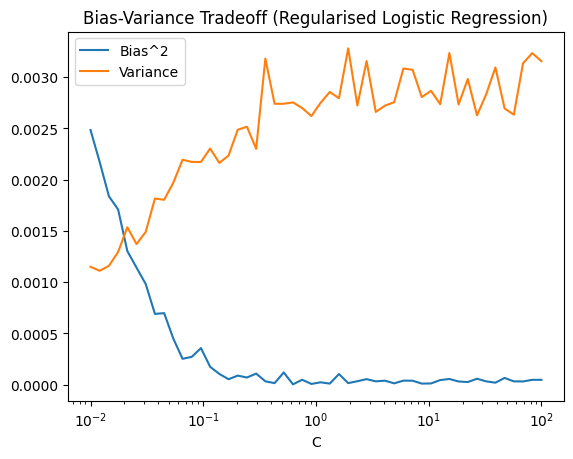

In [7]:
def bias_variance_logistic(C_values, n=200, B=100, N=1000):
    bias_list = []
    var_list = []
    
    np.random.seed(123)
    X, _ = generate_data(N)
    X_design = np.c_[np.ones(X.shape[0]), X] 
    p_true = sigmoid(X_design @ Beta)
    
    for C in C_values:
        preds_all = []
        
        for b in range(B):
            X_train, y_train = generate_data(n)
            scaler = StandardScaler()
            Xt_scaled = scaler.fit_transform(X_train)  
            
            model = LogisticRegression( C=C, fit_intercept=True, random_state=0, max_iter=1000)
            model.fit(Xt_scaled, y_train)

            X_scaled = scaler.transform(X)
            p_hat = model.predict_proba(X_scaled)[:, 1]
            preds_all.append(p_hat)
        
        preds_all = np.array(preds_all)  
        p_mean = preds_all.mean(axis=0)
        
        bias = np.mean((p_mean - p_true)**2)
        var = np.mean(np.var(preds_all, axis=0))
        
        bias_list.append(bias)
        var_list.append(var)
    
    return np.array(bias_list), np.array(var_list)


C_values = np.logspace(-2, 2, 50)  
bias, variance = bias_variance_logistic( C_values, n=200, B=100, N=1000)

plt.figure()
plt.plot(C_values, bias, label="Bias^2")
plt.plot(C_values, variance, label="Variance")
plt.xscale('log')
plt.xlabel("C")
plt.title("Bias-Variance Tradeoff (Regularised Logistic Regression)")
plt.legend()
plt.show()

### Model assessment and selection techniques

Thus far, different attributes of an optimal model have been discussed. The model that minimises the empirical risk or alternatively, the applicable loss function, should be selected for prediction. This model should have the lowest bias and variance and should generalise well. There are two techniques, the validation-set approach and cross-validation, which can be used to select and assess such an optimal model.

The validation-set approach is usually applied when enough data is available. This technique splits all the data into two sets, $\mathcal{D}^*$ and the test set $\mathcal{T}_e$. This is followed by further splitting $\mathcal{D}^*$ into the training set $\mathcal{T}_r$ and validation set $\mathcal{V}$. The algorithm continues by training all possible considered models on $\mathcal{T}_r$. It then selects the model which minimized the empirical risk when applying models to $\mathcal{V}$. Finally, the selected model is assessed on $\mathcal{T}_e$ with metrics such as the generalisation error.

Cross-validation is similar to the validation-set approach, but performs more data partitioning and is often used when there is not a lot of data available. To perform model selection as well as model assessment, all the data, as with the validation-set approach, should be split into two sets, $\mathcal{D}^*$ and the test set $\mathcal{T}_e$. The algorithm then divides $\mathcal{D}^*$ into K mutually exclusive and exhaustive groups $\mathcal{V}^{(k)}:k=1,..,K$ called folds. When K=1, this technique is called leave-one-out cross-validation (LOOCV). Next, each possible model is trained K times, each time, k, on $\mathcal{D}^*$ excluding fold k. It then selects the model, $\hat{f}$, which minimises the cross validation error, cver $(\hat{f},\mathcal{D},K)=\frac{1}{K}\sum^K_{k=1}\hat{\mathcal{R}}(\hat{f}(.,\mathcal{D}^*\backslash \mathcal{V}^{(k)}),\mathcal{V}^{(k)})$ where $\mathcal{D}^*\backslash \mathcal{V}^{(k)}$ refers $\mathcal{D}^*$ excluding fold k. Exactly like the validation-set approach, the selected model is assessed on $\mathcal{T}_e$ with metrics such as the generalisation error. 

Selecting the best model in the regularised logistic regression application, is equavalent to finding the optimal C value. Using 10 fold cross-validation, models with $C\in[0.04,0.07]$, similar than before, minimises the cross-validation error and can be regarded as sensible model selections. Assessing these models with the test errors indicates however that models with C values slighly smaller ($C\in[0.02,0.05]$) yields better generalisation performance for the currect dataset. 

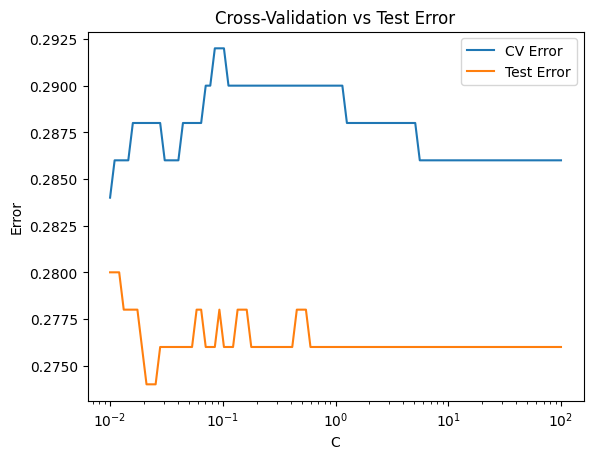

In [8]:
from sklearn.model_selection import KFold

np.random.seed(123)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.5, random_state=0)

def kfold_cv_error(X, y, C, K=5):
    kf = KFold(n_splits=K, shuffle=True, random_state=0)
    
    errors = []
    
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        model = LogisticRegression( C=C, fit_intercept=True, random_state=0, max_iter=1000)
        model.fit(X_tr, y_tr)
        errors.append(zero_one_loss(y_val, model.predict(X_val)))
    
    return np.mean(errors)

C_values = np.logspace(-2, 2, 100)
cv_errors = []
test_errors = []
exp_errors = []

for C in C_values:
    cv_errors.append(kfold_cv_error(X_train, y_train, C, K=10))
    
    model = LogisticRegression( C=C, fit_intercept=True, random_state=0, max_iter=1000)
    model.fit(X_train, y_train)
    test_errors.append(zero_one_loss(y_test, model.predict(X_test)))

    exp_errors.append(estimate_expected_error(X_scaled, y, C=C,B=100))


plt.figure()
plt.plot(C_values, cv_errors, label="CV Error")
plt.plot(C_values, test_errors, label="Test Error")
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Error")
plt.title("Cross-Validation vs Test Error")
plt.legend()
plt.show()


Interestingly, the cross-validation error can also serve as an estimator for the expected generalisation error. This is because models are trained on K different datasets and evaluated on unseen data. Again, the bias-variance trade-off can be observed when choosing the value of K. When K is large, the bias is small and the variance is large since models will be trained and evaluated on more diverse datasets. This concept is visualised with the following plot. 


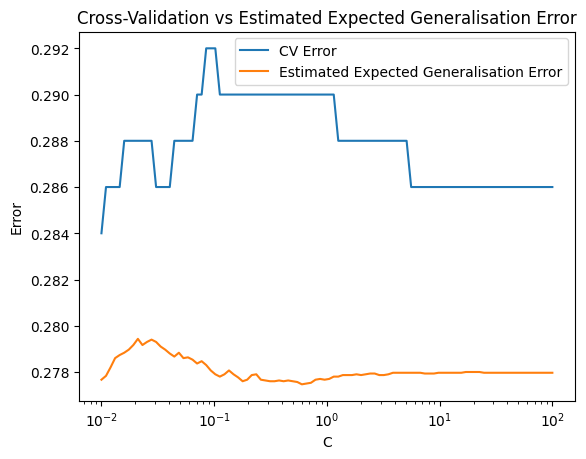

In [10]:

plt.figure()
plt.plot(C_values, cv_errors, label="CV Error")
plt.plot(C_values, exp_errors, label="Estimated Expected Generalisation Error")
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Error")
plt.title("Cross-Validation vs Estimated Expected Generalisation Error")
plt.legend()
plt.show()

### Conclusion
Supervised learning provides a structured framework for predicting responses from observed features, with the choice of loss functions, regularisation, and model selection techniques playing critical roles in achieving optimal performance. Through the logistic regression example, it was shown that while regularisation can improve generalisation, too much penalisation leads to underfitting, and too little risks overfitting. Careful evaluation using training, test, and expected generalisation errors, alongside bias-variance analysis and cross-validation, ensures models achieve the right balance between bias and variance. Ultimately, the effectiveness of supervised learning lies in selecting models that minimise generalisation error while maintaining robustness and interpretability.